# 学習（learning）

このNotebookでやること：

1. 前処理済みデータの読み込み
2. バリデーション戦略の確認（GroupKFold）
3. alphaのチューニング
4. 最終モデルの学習・保存

**入力ファイル（`models/` フォルダ）**

| ファイル | 内容 |
|---|---|
| `models/X_train.npy` | 前処理済みtrain特徴量 |
| `models/y_train.npy` | log変換済みtrain目的変数 |

**出力ファイル（`models/` フォルダ）**

| ファイル | 内容 |
|---|---|
| `models/model.pkl` | 学習済みRidgeモデル |

## 1. ライブラリの読み込み

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import joblib
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

# Noto Sans CJK JP を指定（環境に既存のフォント）
plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['figure.dpi'] = 120

print('ライブラリ読み込み完了')

ライブラリ読み込み完了


## 2. データの読み込み

In [10]:
# 前処理済み特徴量・目的変数
X_train = np.load('models/X_train.npy')
y_train = np.load('models/y_train.npy')  # log変換済み

# GroupKFold用に樹種番号を読み込む
train_raw = pd.read_csv('../data/train.csv', encoding='shift-jis')
train_raw.columns = (
    ['sample_number', 'species_number', 'species_name', 'moisture_content']
    + list(train_raw.columns[4:])
)
groups = train_raw['species_number'].values  # グループ分割のキー

print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'樹種の種類数: {len(np.unique(groups))}')

X_train: (1322, 20)
y_train: (1322,)
樹種の種類数: 13


## 3. バリデーション戦略：GroupKFold

**なぜ通常のKFoldではなくGroupKFoldを使うのか**

通常のKFold（ランダム分割）では、同じ樹種のサンプルがtrainとvalidationの両方に入ります。
するとモデルは「同じ樹種を学習して同じ樹種を予測する」という楽な問題を解くことになり、
スコアが実態より良く見えてしまいます（楽観的バイアス）。

本番のtestデータはtrainにない樹種だけが含まれるため、
「ある樹種が**丸ごと**validationに回る」分割でモデルを評価する必要があります。
これがGroupKFoldです。

```
通常KFold   : [種1,種3,種12] → train  /  [種1,種3,種12の一部] → val  ← NG
GroupKFold  : [種3,種4,種5,種8,種11,種12,種13,種14,種15,種16] → train  /  [種1,種17,種19] → val  ← OK
```

In [11]:
# 変更後
gkf = GroupKFold(n_splits=5)

# ベイスギ（樹種15）をCV評価から除外する
# 理由：ベイスギはスペクトルが他樹種と大きく異なり、testに似た樹種がいない
#       ベイスギ込みのCVはスコアが悪く見えすぎて改善判断の精度が下がるため
mask_cv = (groups != 15)
X_train_cv = X_train[mask_cv]
y_train_cv = y_train[mask_cv]
groups_cv  = groups[mask_cv]

print('GroupKFold の分割確認（ベイスギ除外、各foldのvalidation樹種）')
print('-' * 55)
for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train_cv, y_train_cv, groups_cv)):
    val_species = sorted(np.unique(groups_cv[val_idx]))
    n_val = len(val_idx)
    print(f'Fold {fold+1}: validation樹種={val_species}  ({n_val}サンプル)')

GroupKFold の分割確認（ベイスギ除外、各foldのvalidation樹種）
-------------------------------------------------------
Fold 1: validation樹種=[np.int64(3), np.int64(12)]  (270サンプル)
Fold 2: validation樹種=[np.int64(11), np.int64(14)]  (229サンプル)
Fold 3: validation樹種=[np.int64(4), np.int64(5)]  (201サンプル)
Fold 4: validation樹種=[np.int64(13), np.int64(17), np.int64(19)]  (251サンプル)
Fold 5: validation樹種=[np.int64(1), np.int64(8), np.int64(16)]  (259サンプル)


## 4. alphaのチューニング

Ridge回帰の `alpha` は「過学習をどれだけ抑えるか」を決めるハイパーパラメータです。

- alpha が小さすぎる → 過学習しやすい（trainに過剰適合、testで精度が落ちる）
- alpha が大きすぎる → 過学習は防げるが、表現力が落ちて精度が上がらない

GroupKFoldで複数のalphaを試して、最も良いものを選びます。

In [12]:
alphas = [2500]
results = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    rmse_log_folds  = []
    rmse_orig_folds = []

    # CVはベイスギ除外データで実施
    for tr_idx, val_idx in gkf.split(X_train_cv, y_train_cv, groups_cv):
        model.fit(X_train_cv[tr_idx], y_train_cv[tr_idx])

        y_pred_log  = model.predict(X_train_cv[val_idx])
        y_pred_orig = np.expm1(y_pred_log)
        y_val_orig  = np.expm1(y_train_cv[val_idx])

        rmse_log_folds.append(
            np.sqrt(mean_squared_error(y_train_cv[val_idx], y_pred_log))
        )
        rmse_orig_folds.append(
            np.sqrt(mean_squared_error(y_val_orig, y_pred_orig))
        )

    results.append({
        'alpha'          : alpha,
        'rmse_log_mean'  : np.mean(rmse_log_folds),
        'rmse_log_std'   : np.std(rmse_log_folds),
        'rmse_orig_mean' : np.mean(rmse_orig_folds),
        'rmse_orig_std'  : np.std(rmse_orig_folds),
    })

results_df = pd.DataFrame(results)
print(results_df.round(4).to_string(index=False))
print()

best_row = results_df.loc[results_df['rmse_orig_mean'].idxmin()]
BEST_ALPHA = int(best_row['alpha'])
print(f'最良のalpha: {BEST_ALPHA}  (CV RMSE={best_row["rmse_orig_mean"]:.4f})')

 alpha  rmse_log_mean  rmse_log_std  rmse_orig_mean  rmse_orig_std
  2500         0.4629        0.2009          19.002         7.5077

最良のalpha: 2500  (CV RMSE=19.0020)


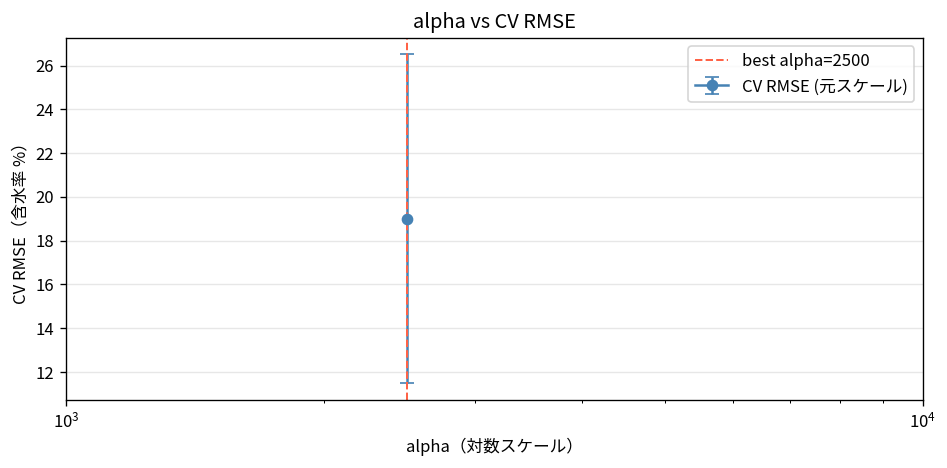

In [13]:
# alphaとRMSEの関係をグラフで確認
fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(
    results_df['alpha'],
    results_df['rmse_orig_mean'],
    yerr=results_df['rmse_orig_std'],
    marker='o', linewidth=1.5, capsize=4, color='steelblue', label='CV RMSE (元スケール)'
)
ax.axvline(BEST_ALPHA, color='tomato', linestyle='--', linewidth=1.2,
           label=f'best alpha={BEST_ALPHA}')
ax.set_xscale('log')
ax.set_xlabel('alpha（対数スケール）')
ax.set_ylabel('CV RMSE（含水率 %）')
ax.set_title('alpha vs CV RMSE')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 最終モデルの学習

最良の alpha を使って、train全データで再学習します。

**なぜ全データで再学習するのか**
バリデーション時は「評価のためにデータの一部をわざとモデルに見せない」という操作をしていました。
最終モデルは提出用なので、より多くのデータで学習した方が精度が上がります。

In [14]:
final_model = Ridge(alpha=BEST_ALPHA)
final_model.fit(X_train, y_train)

# train全体での参考RMSE（過学習の確認用。本番スコアとは異なる）
y_pred_train_log  = final_model.predict(X_train)
y_pred_train_orig = np.expm1(y_pred_train_log)
y_train_orig      = np.expm1(y_train)

train_rmse = np.sqrt(mean_squared_error(y_train_orig, y_pred_train_orig))
print(f'最終モデル（alpha={BEST_ALPHA}）')
print(f'train RMSE（参考値）: {train_rmse:.4f}  ← CV RMSEより低いのは正常')

最終モデル（alpha=2500）
train RMSE（参考値）: 27.2958  ← CV RMSEより低いのは正常


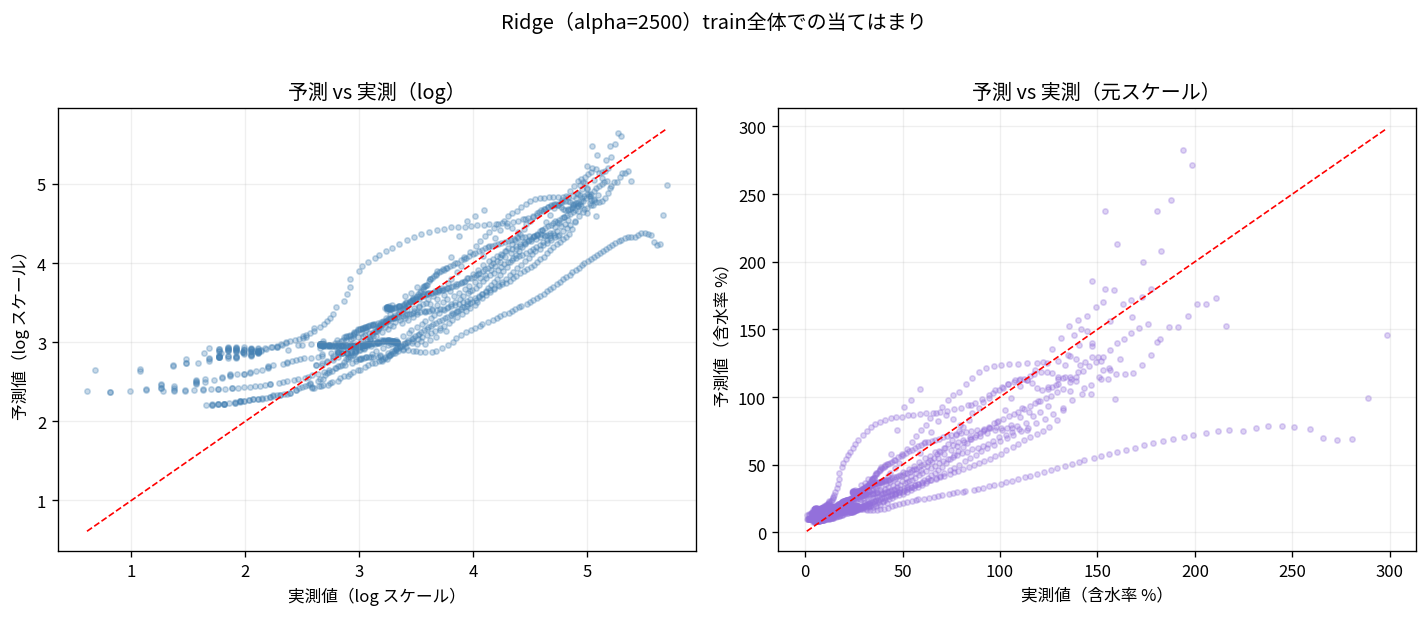

In [15]:
# 予測値 vs 実測値のグラフ（モデルの当てはまりを確認）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# log スケール
axes[0].scatter(y_train, y_pred_train_log, alpha=0.3, s=10, color='steelblue')
lim = [y_train.min(), y_train.max()]
axes[0].plot(lim, lim, 'r--', linewidth=1)
axes[0].set_xlabel('実測値（log スケール）')
axes[0].set_ylabel('予測値（log スケール）')
axes[0].set_title('予測 vs 実測（log）')
axes[0].grid(alpha=0.2)

# 元スケール
axes[1].scatter(y_train_orig, y_pred_train_orig, alpha=0.3, s=10, color='mediumpurple')
lim2 = [y_train_orig.min(), y_train_orig.max()]
axes[1].plot(lim2, lim2, 'r--', linewidth=1)
axes[1].set_xlabel('実測値（含水率 %）')
axes[1].set_ylabel('予測値（含水率 %）')
axes[1].set_title('予測 vs 実測（元スケール）')
axes[1].grid(alpha=0.2)

plt.suptitle(f'Ridge（alpha={BEST_ALPHA}）train全体での当てはまり', y=1.02)
plt.tight_layout()
plt.show()

## 6. モデルの保存

In [16]:
joblib.dump(final_model, 'models/model.pkl')

print('モデル保存完了: models/model.pkl')
print()
print(f'  アルゴリズム : Ridge回帰')
print(f'  alpha        : {BEST_ALPHA}')
print(f'  CV RMSE      : {best_row["rmse_orig_mean"]:.4f} ± {best_row["rmse_orig_std"]:.4f}')
print()
print('次は predicting.ipynb に進んでください。')

モデル保存完了: models/model.pkl

  アルゴリズム : Ridge回帰
  alpha        : 2500
  CV RMSE      : 19.0020 ± 7.5077

次は predicting.ipynb に進んでください。
